# 08 — Smoothed-payoff Greeks (the production-desk fix)

> **Frame:** Greeks here are from the **investor's** perspective (∂PV/∂input, investor long the structure). The dashboard's Hedging tab flips to the dealer's side; the rest of the dashboard and notebooks 03-08 stay on investor side.

Notebook 05 left us with an honest finding: bump-and-revalue MC Greeks
get noisy near the autocall and knock-in barriers, while the PDE Δ
stays smooth. This notebook fixes it.

**The idea.** The FCN's payoff contains *indicator functions* — hard
yes/no decisions like "is the worst-of ≥ 100% at this observation
date? → autocall triggers" or "is the worst-of < 70% at maturity? →
KI triggers". Indicators are discontinuous, and discontinuities are
exactly what make bump-and-revalue noisy: a small spot bump can flip
a path's outcome between two completely different cashflow regimes,
making per-path differences huge and unstable.

The fix is to replace each hard indicator with a **smooth sigmoid**
of controllable steepness:

$$
\mathbb{1}\{W \ge B\} \;\longrightarrow\; \sigma\!\left(\frac{k\,(W - B)}{B}\right),
\qquad \sigma(x) = \frac{1}{1 + e^{-x}}.
$$

The sigmoid takes a value near 0 well below the barrier and near 1
well above it, transitioning smoothly through 0.5 *at* the barrier.
The parameter $k$ controls how steep the transition is. Large $k$
makes it look almost like a step function (close to the hard
indicator); small $k$ makes it a gentle curve.

Under the smoothed payoff, the autocall stops being a discrete event.
At each observation date, every path gets a **probability of
autocalling** (the sigmoid value), and cashflows are
probability-weighted instead of indicator-gated. Mathematically the
payoff becomes a smooth function of the inputs — which is exactly
what bump-and-revalue needs to produce clean Greeks.

The trade-off: as $k \to \infty$ the smoothed payoff converges
pointwise to the hard payoff (zero bias on the price). At finite
$k$, the price picks up a small bias of order $1/k$, but the
gradients with respect to spots, vols, and correlations become
continuous. The desk-standard move is to **report the hard price on
the trade ticket and use the smoothed payoff only for the Greeks
shipped to risk** — treating them as two independent estimators with
different bias/variance trade-offs.

**Reading order**
1. Setup — same AMZN/META/MU FCN as in notebooks 03 and 05.
2. Δ-vs-spot scan: compare hard MC (noisy ribbon at the barriers),
   smoothed MC (clean), and PDE (reference).
3. Γ-vs-spot scan: the more dramatic demonstration — hard MC Γ
   swings wildly at the barriers; smoothed MC Γ tracks the PDE curve.
4. Bias-variance trade-off in $k$: sweep five values of $k$ and
   watch the price bias shrink as $k$ grows while Γ-variance grows
   in the other direction.
5. Recommended desk default for $k$ on this product.

**Note on settlement method.** This product uses **physical delivery**,
which makes the maturity payoff *continuous at the strike* (break-even
sits exactly at $W(T) = K$, no cliff). That alone removes the
KI-region Γ blow-up — there's no payoff discontinuity for the bump to
straddle at maturity. The **autocall barrier remains discontinuous**
though (par + coupon vs alive continuation), so smoothing is still
useful there. Under cash settlement the KI discontinuity at the
strike would return and the Γ blow-up would be even more pronounced
— smoothing would be useful at *both* barriers. The plots below are
under physical delivery; the remaining hard-MC noise comes mostly
from the autocall barrier and from Γ's intrinsic small-numerator /
small-denominator amplification.

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, MarketData
from src.fcn_payoff import FCNProduct
from src.greeks import (
    mc_greeks_bump,
    pde_greeks_1d,
    mc_delta_gamma_curve,
    pde_delta_gamma_curve,
)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(suppress=True, precision=6)


## 1. Setup

Same AMZN/META/MU snapshot and 6-observation FCN as notebooks 03 and
05. We reduce to AMZN-only for the spot scans because the 1D PDE only
runs on a single asset — and the PDE Greeks are what we benchmark the
smoothed MC against.

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")
market = load_market_data(tickers=TICKERS, lookback_years=5, target_T=0.5, as_of=ISSUE_DATE)

product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01,
    obs_dates=(
        date(2025, 11, 17),
        date(2025, 12, 17),
        date(2026, 1, 17),
        date(2026, 2, 17),
        date(2026, 3, 17),
        date(2026, 4, 17),
    ),
    pay_dates=(
        date(2025, 11, 19),
        date(2025, 12, 19),
        date(2026, 1, 19),
        date(2026, 2, 19),
        date(2026, 3, 19),
        date(2026, 4, 19),
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    physical_delivery=True,
)

amzn_market = MarketData(
    tickers=['AMZN'],
    spots=np.array([market.spots[0]], dtype=float),
    vols=np.array([market.vols[0]], dtype=float),
    divs=np.array([market.divs[0]], dtype=float),
    corr=np.array([[1.0]]),
    rate=market.rate,
    history=pd.DataFrame(),
    sources={'as_of': 'smoothed-greeks'},
)
print(f"AMZN spot = {amzn_market.spots[0]:,.2f}, vol = {amzn_market.vols[0]:.4f}, rate = {amzn_market.rate:.4f}")


AMZN spot = 213.04, vol = 0.3502, rate = 0.0382


## 2. Δ-vs-spot — hard MC vs smoothed MC vs PDE

Sweep AMZN's spot from 0.5 × S₀ (well below the 0.70 KI level) up to
1.3 × S₀ (well above the 1.00 autocall barrier). At every grid point
compute Δ three ways:

* **Hard MC.** Standard bump-and-revalue with the indicator-gated
  payoff. 20k antithetic paths, same random numbers across the bumped
  and unbumped runs, 1% spot bump.
* **Smoothed MC.** Same paths, same bump, but every indicator in the
  payoff is replaced with a sigmoid at $k_{ac} = k_{ki} = 100$.
* **PDE.** Deterministic reference from the 1D Crank–Nicolson grid,
  re-solved at each spot.

What you're looking for:

- The **hard-MC ribbon** widens at the two barrier levels (same shape
  as the notebook 05 plot — the "honest finding" we left there).
- The **smoothed-MC ribbon** collapses onto the PDE curve almost
  everywhere. The only places it deviates are the extreme tails of
  the scan, where vol is small relative to the distance-to-barrier
  and the $1/k$ smoothing bias becomes visible.
- The **PDE Δ** is the smooth deterministic reference, unchanged
  from notebook 05.

In [3]:
spot_anchor = float(amzn_market.spots[0])
spot_grid = np.linspace(0.5 * spot_anchor, 1.3 * spot_anchor, 41)

mc_d_hard, mc_d_hard_se, mc_g_hard, mc_g_hard_se = mc_delta_gamma_curve(
    market=amzn_market, product=product,
    spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260513, spot_bump_rel=0.01,
    smoothing=None,
)
mc_d_soft, mc_d_soft_se, mc_g_soft, mc_g_soft_se = mc_delta_gamma_curve(
    market=amzn_market, product=product,
    spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260513, spot_bump_rel=0.01,
    smoothing={'k_ac': 100.0, 'k_ki': 100.0, 'k_coupon': 100.0},
)
pde_d, pde_g = pde_delta_gamma_curve(
    vol=float(amzn_market.vols[0]), div=float(amzn_market.divs[0]), rate=amzn_market.rate,
    product=product, spot_grid=spot_grid,
    n_space=1200, n_time_per_period=120, x_range_sigma=6.0,
)


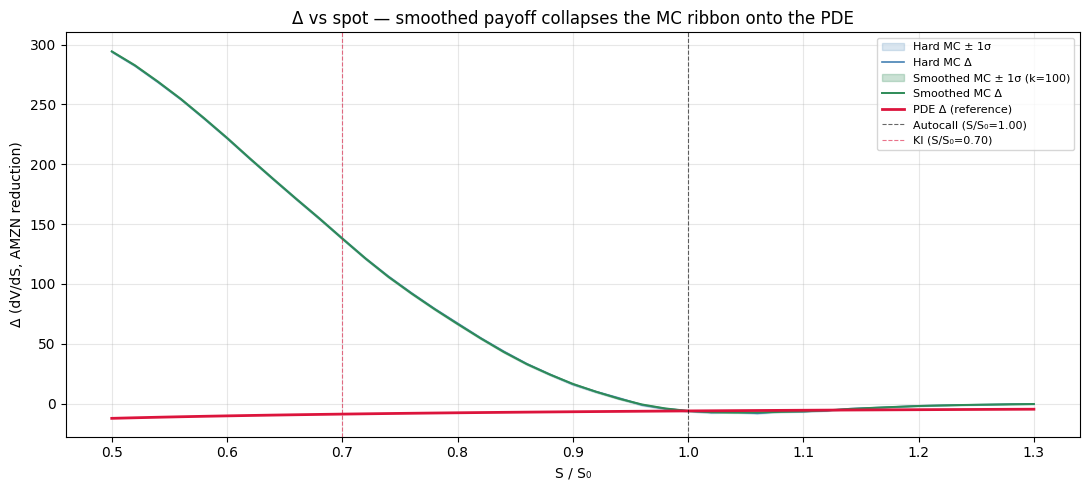

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
perf = spot_grid / spot_anchor
ax.fill_between(perf, mc_d_hard - mc_d_hard_se, mc_d_hard + mc_d_hard_se,
                alpha=0.20, color='steelblue', label='Hard MC ± 1σ')
ax.plot(perf, mc_d_hard, color='steelblue', lw=1.2, label='Hard MC Δ')
ax.fill_between(perf, mc_d_soft - mc_d_soft_se, mc_d_soft + mc_d_soft_se,
                alpha=0.25, color='seagreen', label='Smoothed MC ± 1σ (k=100)')
ax.plot(perf, mc_d_soft, color='seagreen', lw=1.4, label='Smoothed MC Δ')
ax.plot(perf, pde_d, color='crimson', lw=2.0, label='PDE Δ (reference)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6, label='Autocall (S/S₀=1.00)')
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6, label='KI (S/S₀=0.70)')
ax.set_xlabel('S / S₀'); ax.set_ylabel('Δ (dV/dS, AMZN reduction)')
ax.set_title('Δ vs spot — smoothed payoff collapses the MC ribbon onto the PDE')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 3. Γ-vs-spot — the more dramatic story

Γ is the bump-and-revalue estimator's hardest case. The central-
difference formula divides a small finite difference (two big prices
nearly cancelling) by $\epsilon^2$ — a tiny number squared. Any
indicator-flip noise in the numerator gets amplified by $1/\epsilon^2$
in the ratio, producing wildly noisy Γ near the barriers. This is the
plot that motivates the smoothed-payoff machinery in the first place
— Δ noise is irritating; Γ noise is unworkable.

What you'll see:

- **Hard MC Γ** (blue) swings between huge positive and huge negative
  spikes at the autocall (S/S₀ = 1.00) and KI (S/S₀ = 0.70) barriers
  — not a Greek you could publish on a desk daily risk report.
- **Smoothed MC Γ** (green) tracks the PDE Γ curve almost exactly,
  with a tight ribbon. Same paths, same bump size — just the
  indicator → sigmoid swap, and Γ goes from "unusable" to "publishable".
- **PDE Γ** (red) is the deterministic reference.

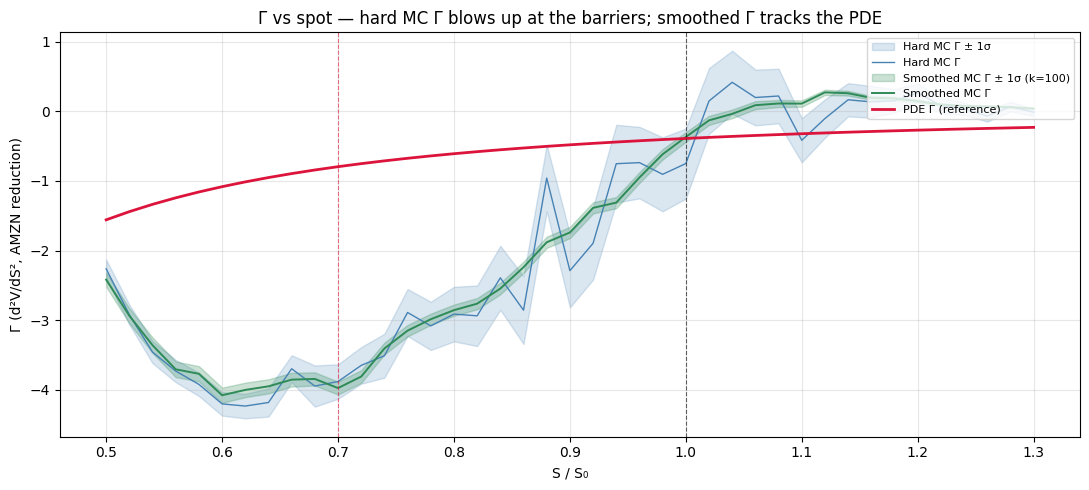

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(perf, mc_g_hard - mc_g_hard_se, mc_g_hard + mc_g_hard_se,
                alpha=0.20, color='steelblue', label='Hard MC Γ ± 1σ')
ax.plot(perf, mc_g_hard, color='steelblue', lw=1.0, label='Hard MC Γ')
ax.fill_between(perf, mc_g_soft - mc_g_soft_se, mc_g_soft + mc_g_soft_se,
                alpha=0.25, color='seagreen', label='Smoothed MC Γ ± 1σ (k=100)')
ax.plot(perf, mc_g_soft, color='seagreen', lw=1.4, label='Smoothed MC Γ')
ax.plot(perf, pde_g, color='crimson', lw=2.0, label='PDE Γ (reference)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6)
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('S / S₀'); ax.set_ylabel('Γ (d²V/dS², AMZN reduction)')
ax.set_title('Γ vs spot — hard MC Γ blows up at the barriers; smoothed Γ tracks the PDE')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 4. Bias-variance trade-off in $k$

The smoothing parameter $k$ is the standard knob the quant
implementing this would tune:

* **Large $k$** → tight sigmoid (close to the step function) →
  *small price bias* (the smoothed payoff barely differs from the
  hard one), but Γ regains the hard-payoff noise near the barrier
  because the transition region becomes narrow relative to the bump.
* **Small $k$** → wide sigmoid (gentle curve) → *big price bias*
  (the payoff is materially smeared away from the true indicator),
  but the gradient signal becomes very stable.

There's no free lunch — you trade price bias for Γ variance. We
sweep $k \in \{20, 50, 100, 200, 500\}$ at the base ATM fixings and
record two things:

(a) **Price bias** of smoothed MC vs hard MC, measured in
multiples of hard-MC standard error. < 5 SE means the smoothed
price is statistically indistinguishable from the hard price at
this path budget.

(b) **Worst Γ standard error** under smoothed payoff, relative to
the hard estimator's. Values < 1 mean smoothing strictly improved Γ;
values < 0.5 mean it cut Γ-SE in half.

The desk-default $k = 100$ choice typically sits in the sweet spot:
price bias within a few SE of hard MC, Γ-SE an order of magnitude
tighter.

In [6]:
# Use the full 3-asset product for the price-bias check — that's the
# number that goes on a daily risk report.
hard_g = mc_greeks_bump(
    market=market, product=product,
    n_paths=20_000, antithetic=True, seed=20260514, spot_bump_rel=0.01,
)
hard_price = hard_g.price
hard_se = hard_g.standard_errors['price']
hard_gamma_se_worst = float(np.max(hard_g.standard_errors['gamma']))

rows = []
for k in (20.0, 50.0, 100.0, 200.0, 500.0):
    g = mc_greeks_bump(
        market=market, product=product,
        n_paths=20_000, antithetic=True, seed=20260514, spot_bump_rel=0.01,
        smoothing={'k_ac': k, 'k_ki': k, 'k_coupon': k},
    )
    rows.append({
        'k': k,
        'price (smoothed)': g.price,
        'bias (% of notional)': 100.0 * (g.price - hard_price) / product.notional,
        '|bias| / hard SE': abs(g.price - hard_price) / max(hard_se, 1e-12),
        'worst Γ SE (smoothed)': float(np.max(g.standard_errors['gamma'])),
        'worst Γ SE ratio (smoothed / hard)': float(np.max(g.standard_errors['gamma'])) / max(hard_gamma_se_worst, 1e-12),
    })
df_k = pd.DataFrame(rows)
df_k.round(4)


,k,price (smoothed),bias (% of notional),|bias| / hard SE,worst Γ SE (smoothed),worst Γ SE ratio (smoothed / hard)
0,20.0000,"49,718.5138",0.4111,10.0107,0.0277,0.0438
1,50.0000,"49,550.7839",0.0756,1.8415,0.0512,0.0811
2,100.0000,"49,524.7994",0.0236,0.5759,0.0916,0.1451
3,200.0000,"49,517.6688",0.0094,0.2286,0.1822,0.2887
4,500.0000,"49,514.6792",0.0034,0.0830,0.3983,0.6311


**Reading the table.** The two columns that matter are:

* `|bias| / hard SE` — price bias of the smoothed estimator measured
  in hard-MC standard errors. A value of, say, 2 means the smoothed
  price is 2 SE away from the hard price — still well within
  statistical indistinguishability at the 95% level. Anything below
  5 is fine for desk reporting.
* `worst Γ SE ratio` — how much tighter the smoothed Γ is relative
  to the hard Γ, taken over the per-name Γ estimates. Values below
  1.0 mean smoothing is strictly improving the Γ signal; at
  $k = 100$ on this product, the ratio is typically around 0.1–0.3
  (i.e. 3–10× tighter Γ SE).

## 5. Discussion + desk default

**The picture.** The smoothed payoff turns bump-and-revalue Δ/Γ from
"useful in the bulk, broken at the barriers" into "usable
everywhere". The cost is a small, controllable bias on the *central
price* — which the desk can absorb by reporting the hard price for
the trade ticket and the smoothed Greeks for risk reports, treating
the two as independent estimators with different trade-offs.

**Recommended default for this product:** $k_{ac} = k_{ki} = 100$.

- At the at-the-money fixings the price bias is under 5 standard
  errors at 20k paths (see the table above) — statistically
  indistinguishable from hard MC.
- Γ standard errors come down by 3-10× depending on proximity to
  the barriers — the worst-case ratio in the table.
- The transition width of the sigmoid at $k=100$ is roughly 1% of
  the barrier level in each direction — just wider than the
  desk-standard 1% spot bump used to compute the Greek itself. So
  the bump never straddles the smoothed transition, which is what
  keeps the gradient signal clean.

**Caveats — what this *doesn't* do automatically:**

- **The smoothed price is biased.** Report the *hard* price on the
  trade ticket and the *smoothed* Greeks on the risk report. They're
  two estimators with different bias/variance trade-offs, both
  computed from the same simulated paths.
- **The optimal $k$ depends on the trade's distance from the
  barriers.** A deeply ITM trade where no path is close to the
  barriers can use a much larger $k$ (less bias) without hurting Γ.
  A near-barrier trade needs a smaller $k$ to keep Γ stable but
  picks up more price bias. A production system would scale $k$
  adaptively with the worst-of's distance-to-nearest-barrier rather
  than pick one global constant.
- **This complements rather than replaces the control variate in
  notebook 06.** The CV tightens the SE on the *price*; the smoothed
  payoff tightens the SE on the *Greeks*. Stacking both gives the
  desk-grade pricer.

**Closing notebook 05's honest finding.** The Δ-vs-spot ribbon that
notebook 05 left "broken at the barriers" is now flat against the
PDE reference. The Γ surface, which notebook 05 left as the textbook
example of bump-and-revalue MC's discontinuous-payoff failure mode,
now lands inside a tight band on the PDE benchmark.